## Final Model and Kaggle Predictions

In [49]:
# import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.impute import KNNImputer
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV


## Preprocessing and Feature Selection pipeline

In [50]:
# import datasets
learn = pd.read_csv("Nata_Files/learn.csv", index_col = 0)
predict = pd.read_csv("Nata_Files/predict.csv", index_col = 0)

In [51]:
# remove duplicates and rows without target in the training set
learn.drop_duplicates(inplace=True)
learn = learn.dropna(axis = 0, subset = ['quality_class'])

In [52]:
# split datasets
train = learn.drop('quality_class', axis=1)
target = learn['quality_class']

In [53]:
# add new columns and drop the ones that aren't used to train the model
train['sugar_content_log'] = np.log(train['sugar_content'])
predict['sugar_content_log'] = np.log(predict['sugar_content'])
train['salt_ratio_log'] = np.log(train['salt_ratio'])
predict['salt_ratio_log'] = np.log(predict['salt_ratio'])
train['baking_duration_log'] = np.log(train['baking_duration'])
predict['baking_duration_log'] = np.log(predict['baking_duration'])
train['preheating_time_log'] = np.log(train['preheating_time'])
predict['preheating_time_log'] = np.log(predict['preheating_time'])
train['vanilla_extract_log'] = np.log(train['vanilla_extract'])
predict['vanilla_extract_log'] = np.log(predict['vanilla_extract'])

for col in ["notes_baker", "pastry_type"]:
    if col in train.columns:
        train = train.drop(columns=[col])
        print(f"Removed column: {col}")
    else:
        print(f"Column '{col}' already erased.")

for col in ["notes_baker", "pastry_type"]:
    if col in predict.columns:
        predict = predict.drop(columns=[col])
        print(f"Removed column: {col}")
    else:
        print(f"Column '{col}' already erased.")


Removed column: notes_baker
Removed column: pastry_type
Removed column: notes_baker
Removed column: pastry_type


In [54]:
# uniformize categorical values and remove NaNs
target = target[~train['origin'].isnull()]
train = train[~train['origin'].isnull()]
train['origin'] = train['origin'].str.strip().str.lower()
predict['origin'] = predict['origin'].str.strip().str.lower()

In [55]:
# encode origin so it can be imputed
train['origin_encoded'] = train['origin'].map({'lisboa': 0, 'porto': 1})
predict['origin_encoded'] = predict['origin'].map({'lisboa': 0, 'porto': 1})
train = train.drop(columns = "origin", axis = 1)
predict = predict.drop(columns = "origin", axis = 1)

In [56]:
knn_imputer = KNNImputer(n_neighbors=6, weights='distance')
train_imputed = knn_imputer.fit_transform(train)
predict_imputed = knn_imputer.transform(predict)
train = pd.DataFrame(train_imputed, columns = train.columns, index = train.index)
predict = pd.DataFrame(predict_imputed, columns= predict.columns, index = predict.index)

In [57]:
train['origin_encoded'] = (train['origin_encoded'] >= 0.5).astype(int)
predict['origin_encoded'] =  (predict['origin_encoded'] >= 0.5).astype(int)
train['origin'] = train['origin_encoded'].map({0: 'lisboa', 1: 'porto'})
predict['origin'] = predict['origin_encoded'].map({0: 'lisboa', 1: 'porto'})
train = train.drop(columns='origin_encoded', axis = 1)
predict = predict.drop(columns='origin_encoded', axis=1)

In [58]:
train = train.drop('oven_temperature', axis = 1)
predict = predict.drop('oven_temperature', axis = 1)

In [59]:
target.value_counts()

quality_class
OK    3201
KO    1836
Name: count, dtype: int64

In [60]:
# # treat outliers
# limits = {
#     #"baking_duration" : (0,45),
#     #"cooling_period" : (0,80),
#     "egg_temperature": (0,170),
#     "egg_yolk_count": (0,15),
#     "final_temperature": (20,450),
#     #"lemon_zest_ph": (2,4),
#     #"oven_temperature": (20,450),
#     #"preheating_time": (100,300),
#     #"salt_ratio": (0,120),
#     "vanilla_extract": (2.5,8.75)
#           }

# for col, (lower, upper) in limits.items():
#     target = target[(train[col] >= lower) & (train[col] <= upper)]
#     train = train[(train[col] >= lower) & (train[col] <= upper)]

In [61]:
# change datatypes to save memory

datatypes = {#'baking_duration': 'int8', 'cooling_period': 'int8', 
             'egg_temperature': 'int16', 'egg_yolk_count': 'int8', 'final_temperature': 'int16', 
             #'lemon_zest_ph': 'float16', 'oven_temperature': 'int16', 
             #'preheating_time': 'int16', 'salt_ratio': 'float16', 
             'vanilla_extract': 'float16', 'sugar_content_log': 'float16', 'baking_duration_log': 'float16',
             'preheating_time_log': 'float16', 'origin': 'category',}
train = train.astype(datatypes)
predict = predict.astype(datatypes)
target = target.astype('category')

In [62]:
# scale datasets
origin_t = train['origin']
origin_p = predict['origin']
train = train.drop('origin', axis=1)
predict = predict.drop('origin', axis=1)

scaler = StandardScaler().fit(train)
# train data
train_scl = scaler.transform(train) 
train = pd.DataFrame(train_scl, columns = train.columns).set_index(train.index)

# prediction data
predict_scl = scaler.transform(predict) 
predict = pd.DataFrame(predict_scl, columns = predict.columns).set_index(predict.index)

train['origin'] = origin_t
predict['origin'] = origin_p

In [63]:
# encode categorical features and target
train['origin'] = train['origin'].replace('porto', 0).replace('lisboa', 1)
predict['origin'] = predict['origin'].replace('porto', 0).replace('lisboa', 1)
target = target.replace('KO', 0).replace('OK', 1)

## Modelling Pipeline

In [64]:
train = train.drop(columns=['ambient_humidity', 'cream_fat_content', 'lemon_zest_ph', 'origin'], axis=1)
predict = predict.drop(columns=['ambient_humidity', 'cream_fat_content', 'lemon_zest_ph', 'origin'], axis=1)

In [65]:
modelet = ExtraTreesClassifier(class_weight='balanced', criterion = 'gini', random_state=1)

# # tune hyperparameters
# param_distributions = {
#     'n_estimators' : [1000], 
#     'max_depth' : [20],
#     'min_samples_split' : [2], 
#     'min_samples_leaf' : [1], 
#     'max_features' : [0.1, 0.09], 
#     'bootstrap' : [False],
#     'class_weight' : ['balanced_subsample'],
#     'criterion' : ['entropy'],
# }

# random_search = RandomizedSearchCV(
#     estimator=modelet,
#     param_distributions=param_distributions,
#     n_iter=80,    
#     cv=5,
#     n_jobs=-1,
#     scoring='accuracy',
#     verbose=1,
#     random_state=42
# )

# # fit model
# random_search.fit(train, target)
# print(random_search.best_params_)
# model = random_search.best_estimator_
# model.fit(train, target)


In [66]:
best_parameters = {}

Fitting 5 folds for each of 14 candidates, totalling 70 fits
                    params  mean_test_score  std_test_score  rank_test_score
13  {'n_estimators': 3000}         0.793130        0.003940                1
3    {'n_estimators': 100}         0.791542        0.005611                2
9   {'n_estimators': 1800}         0.791541        0.006882                3
7   {'n_estimators': 1200}         0.791541        0.005728                4
12  {'n_estimators': 2100}         0.791343        0.005142                5
8   {'n_estimators': 1500}         0.791343        0.005797                6
11  {'n_estimators': 2000}         0.791145        0.005529                7
10  {'n_estimators': 1900}         0.791144        0.006377                8
5    {'n_estimators': 500}         0.790349        0.006564                9
6   {'n_estimators': 1000}         0.790151        0.005783               10
4    {'n_estimators': 200}         0.789754        0.006240               11
2     {'n_estim

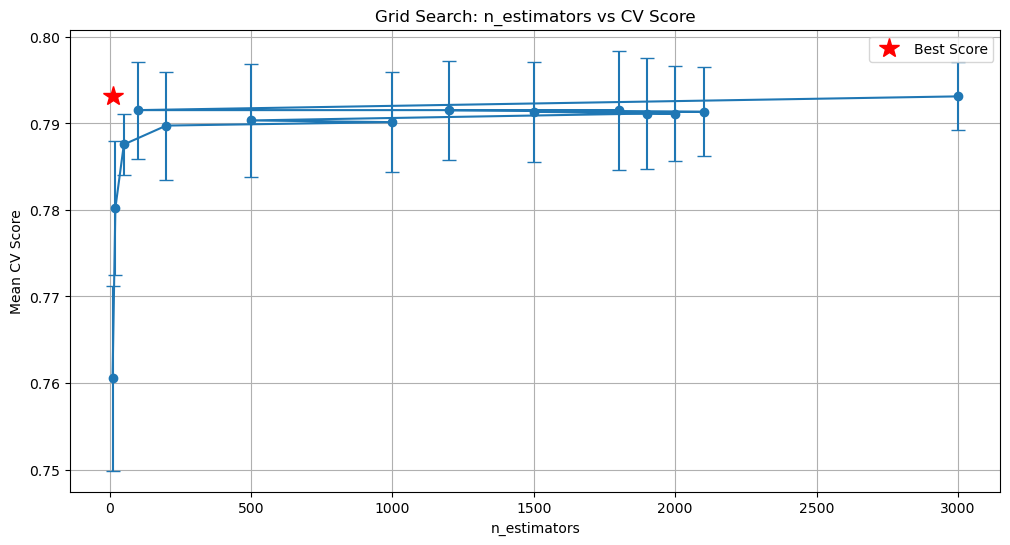

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

# Run GridSearchCV
parameters = {
    'n_estimators': [10, 20, 50, 100, 200, 500, 1000, 1200, 1500, 1800, 1900, 2000, 2100, 3000]
}

clf = GridSearchCV(modelet, parameters, cv=5, verbose=1, n_jobs=-1)
clf.fit(train, target)

# --------------------------
# Table of results
# --------------------------
results = pd.DataFrame(clf.cv_results_)
results = results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results = results.sort_values('rank_test_score')
print(results)

# --------------------------
# Plot results
# --------------------------
x = [p['n_estimators'] for p in results['params']]
y = results['mean_test_score']
yerr = results['std_test_score']

plt.figure(figsize=(12,6))
plt.errorbar(x, y, yerr=yerr, fmt='o-', capsize=5)
plt.xlabel('n_estimators')
plt.ylabel('Mean CV Score')
plt.title('Grid Search: n_estimators vs CV Score')
plt.grid(True)

# Highlight the best score
best_idx = results['rank_test_score'].idxmin()
plt.plot(x[best_idx], y[best_idx], 'r*', markersize=15, label='Best Score')
plt.legend()

plt.show()

use 3000 estimators

In [89]:
best_parameters['n_estimators'] = [100]

Fitting 5 folds for each of 2 candidates, totalling 10 fits
                     params  mean_test_score  std_test_score  rank_test_score
0     {'criterion': 'gini'}         0.791542        0.005611                1
1  {'criterion': 'entropy'}         0.785590        0.010827                2


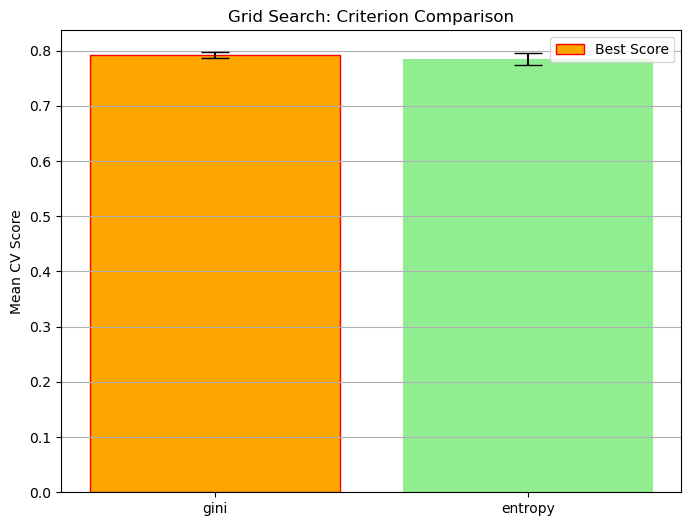

In [20]:
# Grid with only criterion
parameters = {
    'criterion': ['gini', 'entropy']
}

clf = GridSearchCV(modelet, parameters, cv=5, verbose=1, n_jobs=-1)
clf.fit(train, target)

# --------------------------
# Table of results
# --------------------------
results = pd.DataFrame(clf.cv_results_)
results = results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results = results.sort_values('rank_test_score')
print(results)

# --------------------------
# Plot results
# --------------------------
x = [p['criterion'] for p in results['params']]
y = results['mean_test_score']
yerr = results['std_test_score']

plt.figure(figsize=(8,6))
plt.bar(x, y, yerr=yerr, capsize=10, color=['skyblue', 'lightgreen'])
plt.ylabel('Mean CV Score')
plt.title('Grid Search: Criterion Comparison')
plt.grid(axis='y')

# Highlight the best criterion
best_idx = results['rank_test_score'].idxmin()
plt.bar(x[best_idx], y[best_idx], color='orange', edgecolor='red', label='Best Score')
plt.legend()
plt.show()


use gini

In [81]:
best_parameters['criterion'] = ['gini']

Fitting 5 folds for each of 14 candidates, totalling 70 fits
                 params  mean_test_score  std_test_score  rank_test_score
11    {'max_depth': 31}         0.792733        0.004588                1
10    {'max_depth': 30}         0.791542        0.005862                2
13  {'max_depth': None}         0.791542        0.005611                3
9     {'max_depth': 29}         0.791342        0.005160                4
7     {'max_depth': 27}         0.790948        0.007800                5
8     {'max_depth': 28}         0.790152        0.004739                6
12    {'max_depth': 32}         0.789954        0.007825                7
2     {'max_depth': 22}         0.789757        0.006884                8
3     {'max_depth': 23}         0.788962        0.003609                9
5     {'max_depth': 25}         0.788763        0.002311               10
6     {'max_depth': 26}         0.788564        0.008876               11
1     {'max_depth': 21}         0.787177        0.0

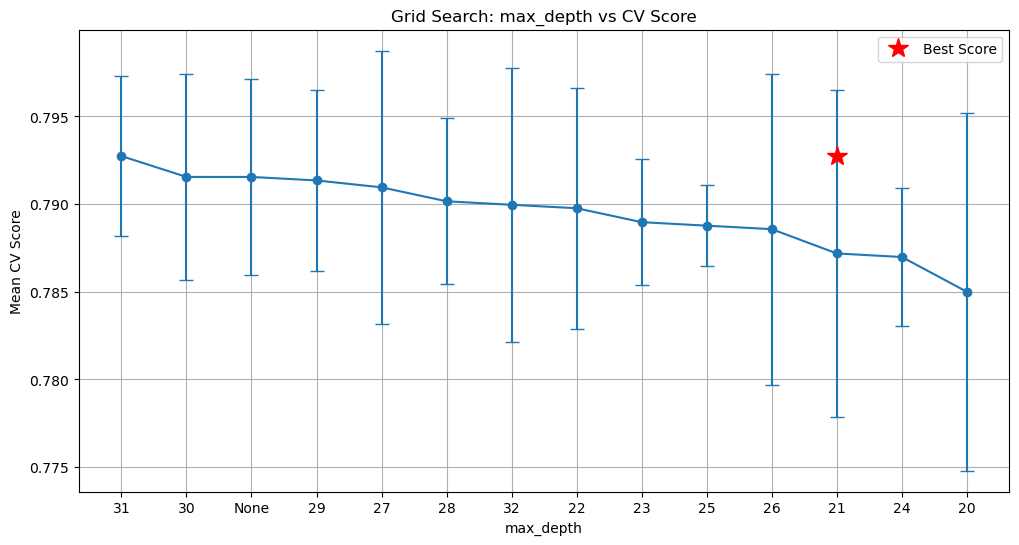

In [26]:
# Grid with only max_depth
parameters = {
    'max_depth': [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, None]
}

clf = GridSearchCV(modelet, parameters, cv=5, verbose=1, n_jobs=-1)
clf.fit(train, target)

# --------------------------
# Table of results
# --------------------------
results = pd.DataFrame(clf.cv_results_)
results = results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results = results.sort_values('rank_test_score')
print(results)

# --------------------------
# Plot results
# --------------------------
x = [str(p['max_depth']) for p in results['params']]  # convert None to string for plotting
y = results['mean_test_score']
yerr = results['std_test_score']

plt.figure(figsize=(12,6))
plt.errorbar(x, y, yerr=yerr, fmt='o-', capsize=5)
plt.xlabel('max_depth')
plt.ylabel('Mean CV Score')
plt.title('Grid Search: max_depth vs CV Score')
plt.grid(True)

# Highlight the best score
best_idx = results['rank_test_score'].idxmin()
plt.plot(x[best_idx], y[best_idx], 'r*', markersize=15, label='Best Score')
plt.legend()
plt.show()


use max_depth = 31

In [82]:
best_parameters['max_depth'] = [31]

Fitting 5 folds for each of 12 candidates, totalling 60 fits
                        params  mean_test_score  std_test_score  \
1     {'min_samples_split': 2}         0.791542        0.005611   
2     {'min_samples_split': 5}         0.782806        0.003747   
3     {'min_samples_split': 8}         0.781023        0.011531   
4    {'min_samples_split': 13}         0.769309        0.009360   
5    {'min_samples_split': 21}         0.759382        0.009573   
6    {'min_samples_split': 34}         0.755412        0.010428   
7    {'min_samples_split': 55}         0.748859        0.006150   
8    {'min_samples_split': 89}         0.743699        0.012429   
9   {'min_samples_split': 144}         0.737743        0.011263   
10  {'min_samples_split': 233}         0.731787        0.009699   
11  {'min_samples_split': 377}         0.725633        0.010850   
0     {'min_samples_split': 1}              NaN             NaN   

    rank_test_score  
1                 1  
2                 2  
3

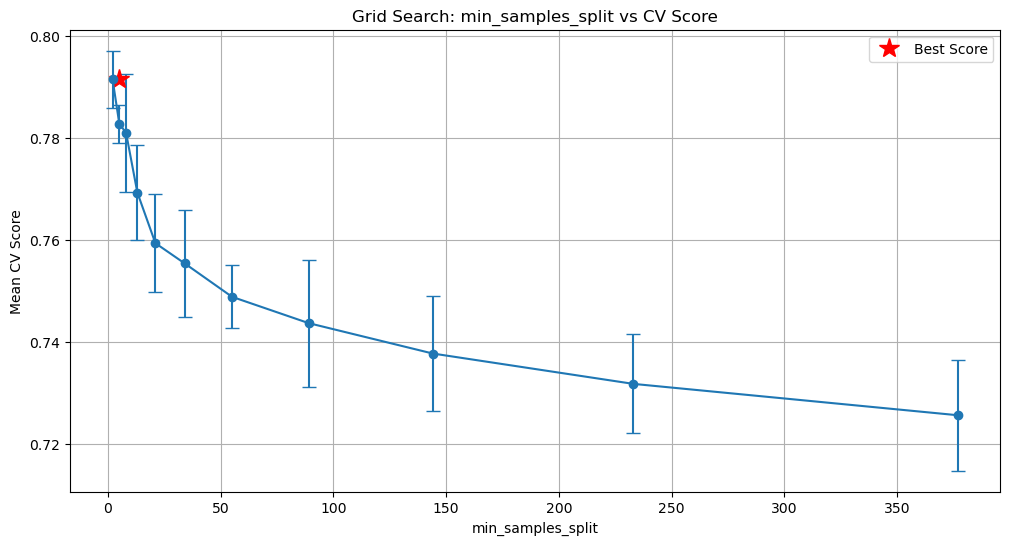

In [28]:
# Grid with only min_samples_split
parameters = {
    'min_samples_split': [1, 2, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377]
}

clf = GridSearchCV(modelet, parameters, cv=5, verbose=1, n_jobs=-1)
clf.fit(train, target)

# --------------------------
# Table of results
# --------------------------
results = pd.DataFrame(clf.cv_results_)
results = results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results = results.sort_values('rank_test_score')
print(results)

# --------------------------
# Plot results
# --------------------------
x = [p['min_samples_split'] for p in results['params']]
y = results['mean_test_score']
yerr = results['std_test_score']

plt.figure(figsize=(12,6))
plt.errorbar(x, y, yerr=yerr, fmt='o-', capsize=5)
plt.xlabel('min_samples_split')
plt.ylabel('Mean CV Score')
plt.title('Grid Search: min_samples_split vs CV Score')
plt.grid(True)

# Highlight the best score
best_idx = results['rank_test_score'].idxmin()
plt.plot(x[best_idx], y[best_idx], 'r*', markersize=15, label='Best Score')
plt.legend()
plt.show()


use 2

In [83]:
best_parameters['min_samples_split'] = [2]

Fitting 5 folds for each of 12 candidates, totalling 60 fits
                       params  mean_test_score  std_test_score  \
0     {'min_samples_leaf': 1}         0.791542        0.005611   
1     {'min_samples_leaf': 2}         0.777646        0.009335   
2     {'min_samples_leaf': 5}         0.755214        0.009702   
3     {'min_samples_leaf': 8}         0.749853        0.010072   
4    {'min_samples_leaf': 13}         0.742506        0.007244   
5    {'min_samples_leaf': 21}         0.736550        0.007590   
6    {'min_samples_leaf': 34}         0.728812        0.013444   
7    {'min_samples_leaf': 55}         0.726427        0.010218   
8    {'min_samples_leaf': 89}         0.714912        0.009905   
10  {'min_samples_leaf': 233}         0.714714        0.011111   
9   {'min_samples_leaf': 144}         0.713123        0.005509   
11  {'min_samples_leaf': 377}         0.698433        0.008416   

    rank_test_score  
0                 1  
1                 2  
2             

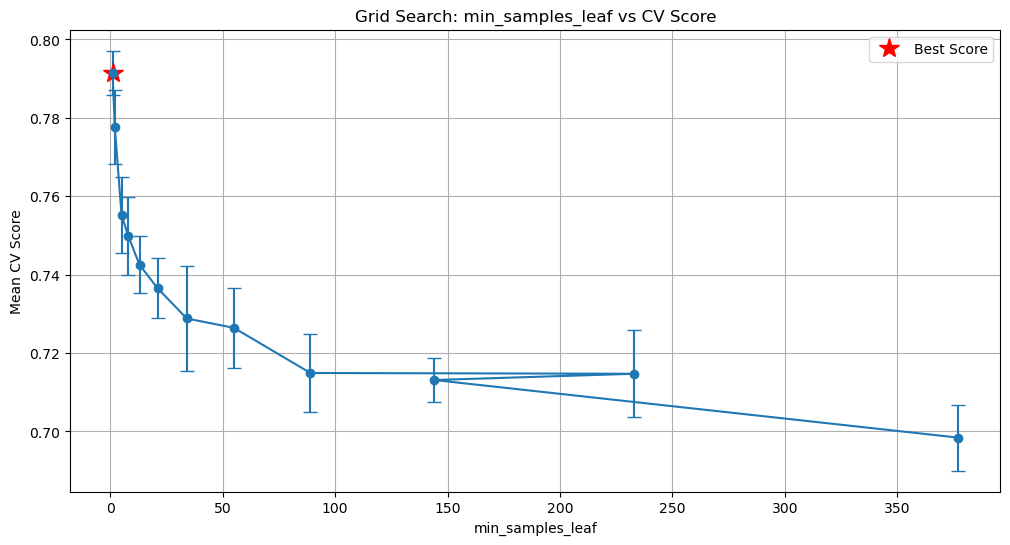

In [30]:
# Grid with only min_samples_leaf
parameters = {
    'min_samples_leaf': [1, 2, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377]
}

clf = GridSearchCV(modelet, parameters, cv=5, verbose=1, n_jobs=-1)
clf.fit(train, target)

# --------------------------
# Table of results
# --------------------------
results = pd.DataFrame(clf.cv_results_)
results = results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results = results.sort_values('rank_test_score')
print(results)

# --------------------------
# Plot results
# --------------------------
x = [p['min_samples_leaf'] for p in results['params']]
y = results['mean_test_score']
yerr = results['std_test_score']

plt.figure(figsize=(12,6))
plt.errorbar(x, y, yerr=yerr, fmt='o-', capsize=5)
plt.xlabel('min_samples_leaf')
plt.ylabel('Mean CV Score')
plt.title('Grid Search: min_samples_leaf vs CV Score')
plt.grid(True)

# Highlight the best score
best_idx = results['rank_test_score'].idxmin()
plt.plot(x[best_idx], y[best_idx], 'r*', markersize=15, label='Best Score')
plt.legend()
plt.show()


use 1

In [84]:
best_parameters['min_samples_leaf'] = [1]

Fitting 5 folds for each of 6 candidates, totalling 30 fits
                              params  mean_test_score  std_test_score  \
0  {'min_weight_fraction_leaf': 0.0}         0.791542        0.005611   
1  {'min_weight_fraction_leaf': 0.1}         0.696646        0.007432   
3  {'min_weight_fraction_leaf': 0.3}         0.682745        0.024650   
2  {'min_weight_fraction_leaf': 0.2}         0.680172        0.009996   
4  {'min_weight_fraction_leaf': 0.4}         0.610886        0.015157   
5  {'min_weight_fraction_leaf': 0.5}         0.418868        0.108523   

   rank_test_score  
0                1  
1                2  
3                3  
2                4  
4                5  
5                6  


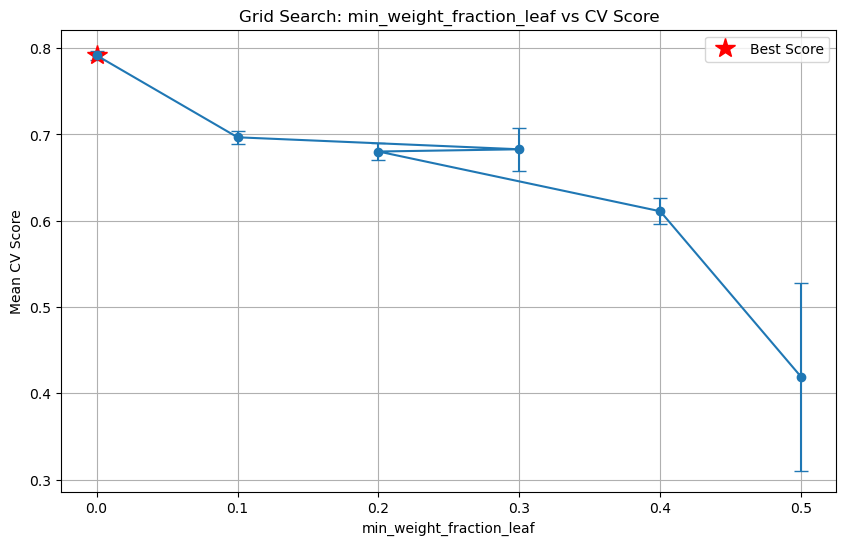

In [31]:
# Grid with min_weight_fraction_leaf from 0.0 to 0.5
parameters = {
    'min_weight_fraction_leaf': [x / 10 for x in range(0, 6)]  # [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
}

clf = GridSearchCV(modelet, parameters, cv=5, verbose=1, n_jobs=-1)
clf.fit(train, target)

# --------------------------
# Table of results
# --------------------------
results = pd.DataFrame(clf.cv_results_)
results = results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results = results.sort_values('rank_test_score')
print(results)

# --------------------------
# Plot results
# --------------------------
x = [p['min_weight_fraction_leaf'] for p in results['params']]
y = results['mean_test_score']
yerr = results['std_test_score']

plt.figure(figsize=(10,6))
plt.errorbar(x, y, yerr=yerr, fmt='o-', capsize=5)
plt.xlabel('min_weight_fraction_leaf')
plt.ylabel('Mean CV Score')
plt.title('Grid Search: min_weight_fraction_leaf vs CV Score')
plt.grid(True)

# Highlight the best score
best_idx = results['rank_test_score'].idxmin()
plt.plot(x[best_idx], y[best_idx], 'r*', markersize=15, label='Best Score')
plt.legend()
plt.show()


better with the default value

Fitting 5 folds for each of 13 candidates, totalling 65 fits
                          params  mean_test_score  std_test_score  \
1       {'max_features': 'sqrt'}         0.791542        0.005611   
2       {'max_features': 'log2'}         0.791542        0.005611   
6          {'max_features': 0.3}         0.790351        0.008138   
3          {'max_features': 0.1}         0.788365        0.008561   
4         {'max_features': 0.09}         0.788365        0.008561   
5         {'max_features': 0.12}         0.788365        0.008561   
8          {'max_features': 0.7}         0.784991        0.005898   
7          {'max_features': 0.5}         0.783599        0.006253   
9          {'max_features': 0.9}         0.777647        0.005452   
10         {'max_features': 1.0}         0.775462        0.005977   
11        {'max_features': None}         0.775462        0.005977   
0       {'max_features': 'auto'}              NaN             NaN   
12  {'max_features': 'log_loss'}          

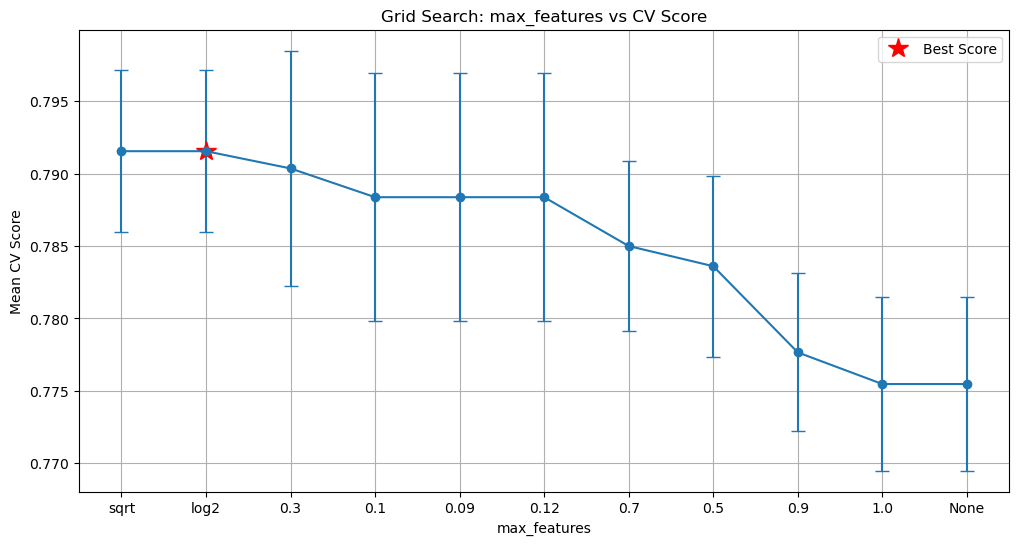

In [35]:
# Grid with max_features options
parameters = {
    'max_features': ['auto', 'sqrt', 'log2', 0.1, 0.09, 0.12, 0.3, 0.5, 0.7, 0.9, 1.0, None, 'log_loss']
}

clf = GridSearchCV(modelet, parameters, cv=5, verbose=1, n_jobs=-1)
clf.fit(train, target)

# --------------------------
# Table of results
# --------------------------
results = pd.DataFrame(clf.cv_results_)
results = results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results = results.sort_values('rank_test_score')
print(results)

# --------------------------
# Plot results
# --------------------------
x_labels = [str(p['max_features']) for p in results['params']]  # convert None to string
y = results['mean_test_score']
yerr = results['std_test_score']

plt.figure(figsize=(12,6))
plt.errorbar(x_labels, y, yerr=yerr, fmt='o-', capsize=5)
plt.xlabel('max_features')
plt.ylabel('Mean CV Score')
plt.title('Grid Search: max_features vs CV Score')
plt.grid(True)

# Highlight the best score
best_idx = results['rank_test_score'].idxmin()
plt.plot(x_labels[best_idx], y[best_idx], 'r*', markersize=15, label='Best Score')
plt.legend()
plt.show()


maybe try with both idk

In [74]:
best_parameters['max_features'] = ['sqrt', 'log2']

Fitting 5 folds for each of 13 candidates, totalling 65 fits
                      params  mean_test_score  std_test_score  rank_test_score
12  {'max_leaf_nodes': None}         0.791542        0.005611                1
11  {'max_leaf_nodes': 1000}         0.784000        0.004480                2
10   {'max_leaf_nodes': 377}         0.769309        0.011500                3
9    {'max_leaf_nodes': 233}         0.757793        0.011693                4
8    {'max_leaf_nodes': 144}         0.749256        0.010935                5
7     {'max_leaf_nodes': 89}         0.745088        0.010164                6
6     {'max_leaf_nodes': 55}         0.737742        0.014148                7
5     {'max_leaf_nodes': 34}         0.732977        0.010989                8
4     {'max_leaf_nodes': 21}         0.727816        0.013554                9
3     {'max_leaf_nodes': 13}         0.721861        0.012291               10
2      {'max_leaf_nodes': 8}         0.718287        0.009762         

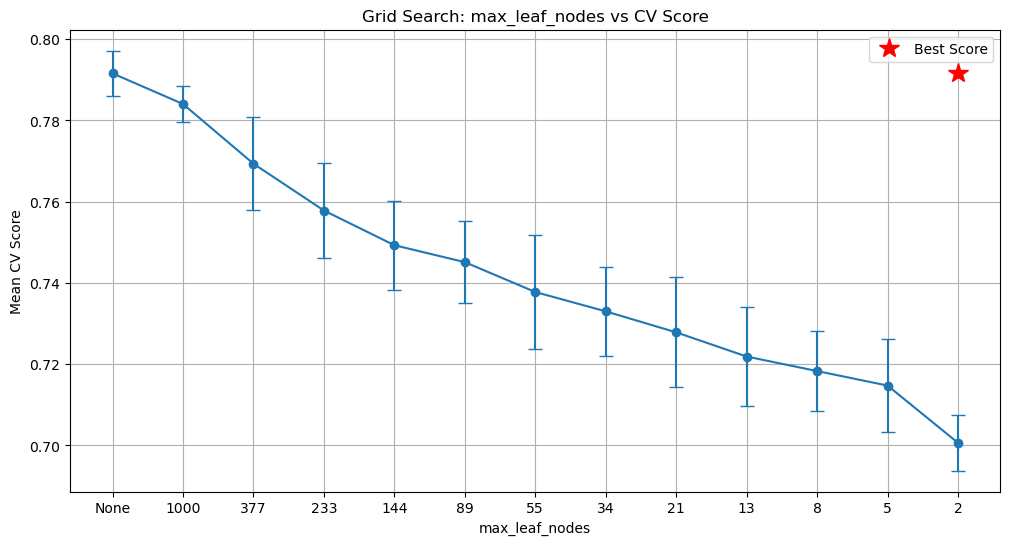

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

# Grid with max_leaf_nodes options
parameters = {
    'max_leaf_nodes': [2, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 1000, None]
}

clf = GridSearchCV(modelet, parameters, cv=5, verbose=1, n_jobs=-1)
clf.fit(train, target)

# --------------------------
# Table of results
# --------------------------
results = pd.DataFrame(clf.cv_results_)
results = results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results = results.sort_values('rank_test_score')
print(results)

# --------------------------
# Plot results
# --------------------------
x_labels = [str(p['max_leaf_nodes']) for p in results['params']]  # convert None to string
y = results['mean_test_score']
yerr = results['std_test_score']

plt.figure(figsize=(12,6))
plt.errorbar(x_labels, y, yerr=yerr, fmt='o-', capsize=5)
plt.xlabel('max_leaf_nodes')
plt.ylabel('Mean CV Score')
plt.title('Grid Search: max_leaf_nodes vs CV Score')
plt.grid(True)

# Highlight the best score
best_idx = results['rank_test_score'].idxmin()
plt.plot(x_labels[best_idx], y[best_idx], 'r*', markersize=15, label='Best Score')
plt.legend()
plt.show()


use none

In [85]:
best_parameters['max_leaf_nodes'] = [None]

Fitting 5 folds for each of 11 candidates, totalling 55 fits
                             params  mean_test_score  std_test_score  \
0    {'min_impurity_decrease': 0.0}         0.791542        0.005611   
1   {'min_impurity_decrease': 0.01}         0.712328        0.004705   
2   {'min_impurity_decrease': 0.02}         0.702606        0.011647   
3   {'min_impurity_decrease': 0.03}         0.660708        0.010407   
4   {'min_impurity_decrease': 0.04}         0.660708        0.010407   
5   {'min_impurity_decrease': 0.05}         0.660708        0.010407   
6   {'min_impurity_decrease': 0.06}         0.660708        0.010407   
7   {'min_impurity_decrease': 0.07}         0.660708        0.010407   
8   {'min_impurity_decrease': 0.08}         0.418868        0.108523   
9   {'min_impurity_decrease': 0.09}         0.418868        0.108523   
10   {'min_impurity_decrease': 0.1}         0.418868        0.108523   

    rank_test_score  
0                 1  
1                 2  
2       

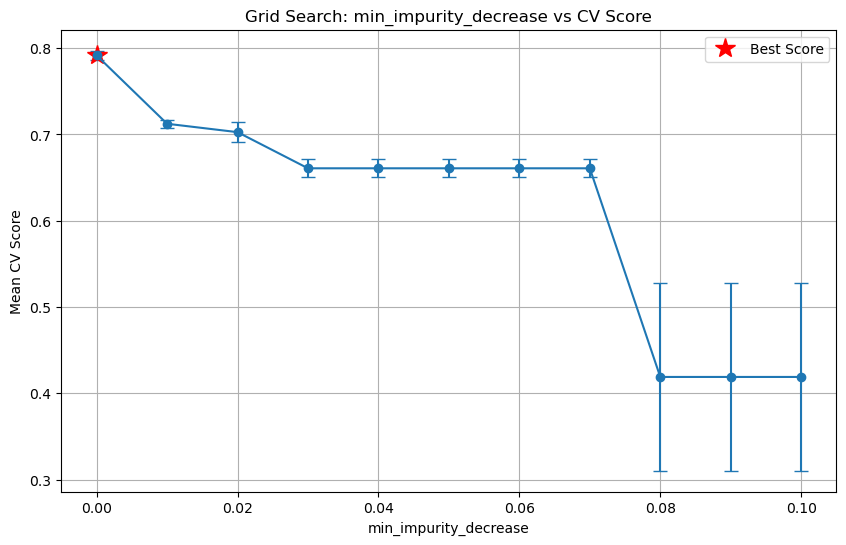

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

# Grid with min_impurity_decrease from 0.0 to 0.1
parameters = {
    'min_impurity_decrease': [x / 100 for x in range(0, 11)]  # [0.0, 0.01, ..., 0.1]
}

clf = GridSearchCV(modelet, parameters, cv=5, verbose=1, n_jobs=-1)
clf.fit(train, target)

# --------------------------
# Table of results
# --------------------------
results = pd.DataFrame(clf.cv_results_)
results = results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results = results.sort_values('rank_test_score')
print(results)

# --------------------------
# Plot results
# --------------------------
x = [p['min_impurity_decrease'] for p in results['params']]
y = results['mean_test_score']
yerr = results['std_test_score']

plt.figure(figsize=(10,6))
plt.errorbar(x, y, yerr=yerr, fmt='o-', capsize=5)
plt.xlabel('min_impurity_decrease')
plt.ylabel('Mean CV Score')
plt.title('Grid Search: min_impurity_decrease vs CV Score')
plt.grid(True)

# Highlight the best score
best_idx = results['rank_test_score'].idxmin()
plt.plot(x[best_idx], y[best_idx], 'r*', markersize=15, label='Best Score')
plt.legend()
plt.show()


default value

Fitting 5 folds for each of 2 candidates, totalling 10 fits
                 params  mean_test_score  std_test_score  rank_test_score
1  {'bootstrap': False}         0.791542        0.005611                1
0   {'bootstrap': True}         0.782807        0.004762                2


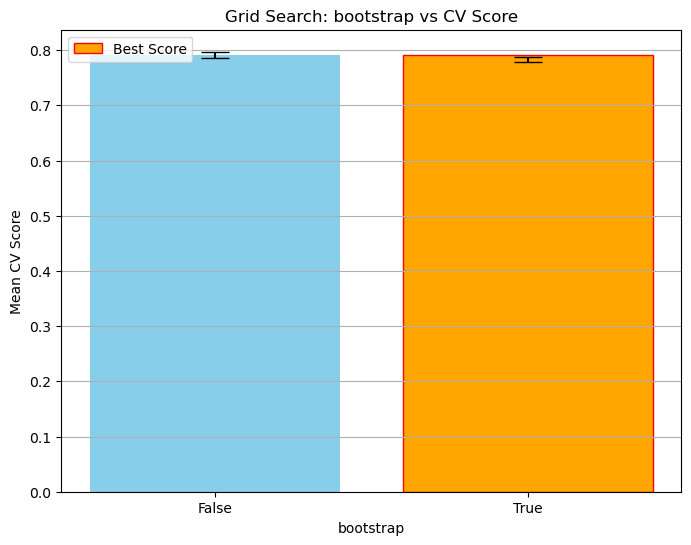

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

# Grid with bootstrap options
parameters = {
    'bootstrap': [True, False]
}

clf = GridSearchCV(modelet, parameters, cv=5, verbose=1, n_jobs=-1)
clf.fit(train, target)

# --------------------------
# Table of results
# --------------------------
results = pd.DataFrame(clf.cv_results_)
results = results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results = results.sort_values('rank_test_score')
print(results)

# --------------------------
# Plot results
# --------------------------
x = [str(p['bootstrap']) for p in results['params']]  # convert to string for plotting
y = results['mean_test_score']
yerr = results['std_test_score']

plt.figure(figsize=(8,6))
plt.bar(x, y, yerr=yerr, capsize=10, color=['skyblue', 'lightgreen'])
plt.xlabel('bootstrap')
plt.ylabel('Mean CV Score')
plt.title('Grid Search: bootstrap vs CV Score')
plt.grid(axis='y')

# Highlight the best score
best_idx = results['rank_test_score'].idxmin()
plt.bar(x[best_idx], y[best_idx], color='orange', edgecolor='red', label='Best Score')
plt.legend()
plt.show()


Fitting 5 folds for each of 2 candidates, totalling 10 fits
                                    params  mean_test_score  std_test_score  \
0   {'bootstrap': True, 'oob_score': True}         0.782807        0.004762   
1  {'bootstrap': True, 'oob_score': False}         0.782807        0.004762   

   rank_test_score  
0                1  
1                1  


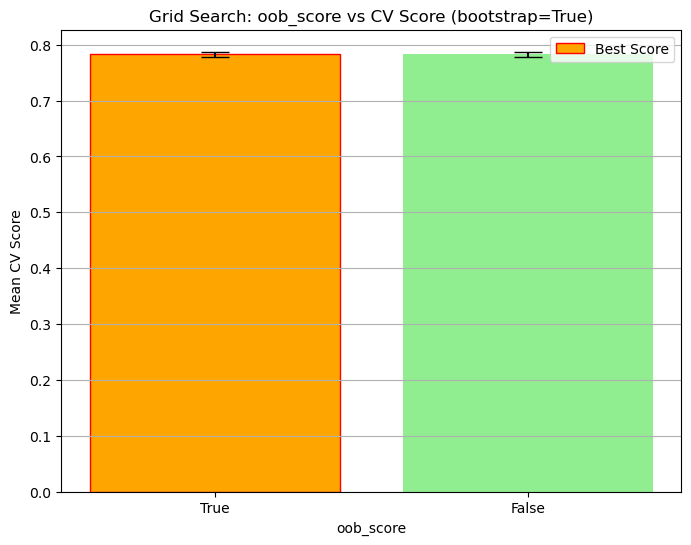

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

# Grid with oob_score (bootstrap must be True)
parameters = {
    'bootstrap': [True],
    'oob_score': [True, False]
}

clf = GridSearchCV(modelet, parameters, cv=5, verbose=1, n_jobs=-1)
clf.fit(train, target)

# --------------------------
# Table of results
# --------------------------
results = pd.DataFrame(clf.cv_results_)
results = results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results = results.sort_values('rank_test_score')
print(results)

# --------------------------
# Plot results
# --------------------------
x = [str(p['oob_score']) for p in results['params']]  # convert to string for plotting
y = results['mean_test_score']
yerr = results['std_test_score']

plt.figure(figsize=(8,6))
plt.bar(x, y, yerr=yerr, capsize=10, color=['skyblue', 'lightgreen'])
plt.xlabel('oob_score')
plt.ylabel('Mean CV Score')
plt.title('Grid Search: oob_score vs CV Score (bootstrap=True)')
plt.grid(axis='y')

# Highlight the best score
best_idx = results['rank_test_score'].idxmin()
plt.bar(x[best_idx], y[best_idx], color='orange', edgecolor='red', label='Best Score')
plt.legend()
plt.show()


use bootstrap false

In [86]:
best_parameters['bootstrap'] = [False]

Fitting 5 folds for each of 2 candidates, totalling 10 fits


/opt/anaconda3/envs/machine_learning/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(
/opt/anaconda3/envs/machine_learning/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequen

                  params  mean_test_score  std_test_score  rank_test_score
0   {'warm_start': True}         0.791542        0.005611                1
1  {'warm_start': False}         0.791542        0.005611                1


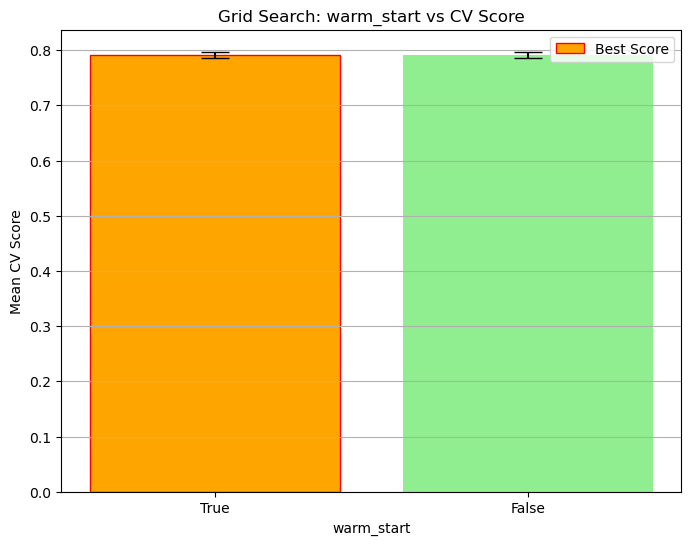

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

# Grid with warm_start options
parameters = {
    'warm_start': [True, False]
}

clf = GridSearchCV(modelet, parameters, cv=5, verbose=1, n_jobs=-1)
clf.fit(train, target)

# --------------------------
# Table of results
# --------------------------
results = pd.DataFrame(clf.cv_results_)
results = results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results = results.sort_values('rank_test_score')
print(results)

# --------------------------
# Plot results
# --------------------------
x = [str(p['warm_start']) for p in results['params']]  # convert to string for plotting
y = results['mean_test_score']
yerr = results['std_test_score']

plt.figure(figsize=(8,6))
plt.bar(x, y, yerr=yerr, capsize=10, color=['skyblue', 'lightgreen'])
plt.xlabel('warm_start')
plt.ylabel('Mean CV Score')
plt.title('Grid Search: warm_start vs CV Score')
plt.grid(axis='y')

# Highlight the best score
best_idx = results['rank_test_score'].idxmin()
plt.bar(x[best_idx], y[best_idx], color='orange', edgecolor='red', label='Best Score')
plt.legend()
plt.show()


maybe try with both idk

In [77]:
best_parameters['warm_start'] = [True, False]

Custom class weight: {0: np.float64(2.7434640522875817), 1: np.float64(1.5735707591377694)}
Fitting 5 folds for each of 4 candidates, totalling 20 fits
                                              params  mean_test_score  \
3  {'class_weight': {0: 2.7434640522875817, 1: 1....         0.794918   
2                             {'class_weight': None}         0.793925   
0                       {'class_weight': 'balanced'}         0.791542   
1             {'class_weight': 'balanced_subsample'}         0.791542   

   std_test_score  rank_test_score  
3        0.004417                1  
2        0.005363                2  
0        0.005611                3  
1        0.005611                3  


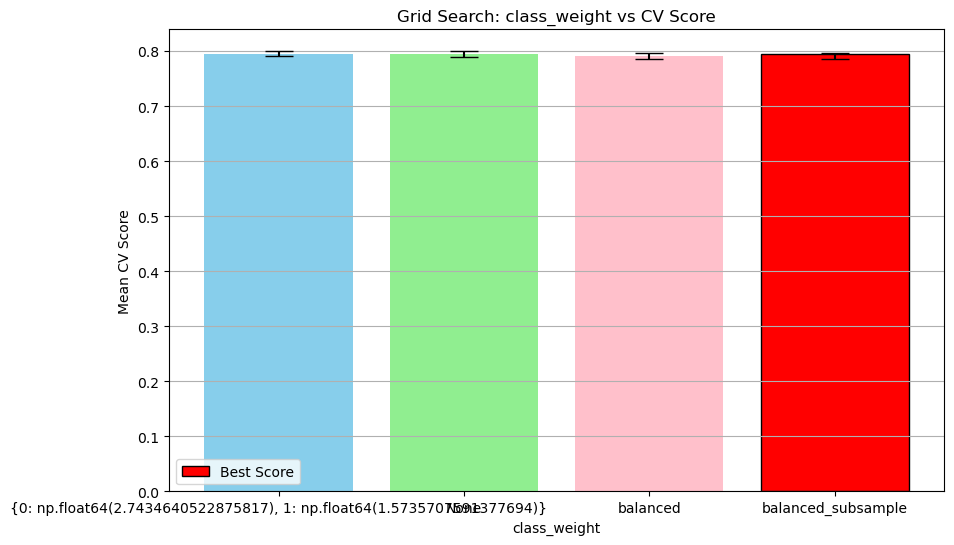

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_class_weight

# Example: compute custom weights manually
import numpy as np
counts = np.array([1836, 3201])
total = counts.sum()
custom_weight = {0: total/counts[0], 1: total/counts[1]}
print("Custom class weight:", custom_weight)

# Grid with class_weight options
parameters = {
    'class_weight': ['balanced', 'balanced_subsample', None, custom_weight]
}

clf = GridSearchCV(modelet, parameters, cv=5, verbose=1, n_jobs=-1)
clf.fit(train, target)

# --------------------------
# Table of results
# --------------------------
results = pd.DataFrame(clf.cv_results_)
results = results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results = results.sort_values('rank_test_score')
print(results)

# --------------------------
# Plot results
# --------------------------
x_labels = [str(p['class_weight']) for p in results['params']]
y = results['mean_test_score']
yerr = results['std_test_score']

plt.figure(figsize=(10,6))
plt.bar(x_labels, y, yerr=yerr, capsize=10, color=['skyblue', 'lightgreen', 'pink', 'orange'])
plt.xlabel('class_weight')
plt.ylabel('Mean CV Score')
plt.title('Grid Search: class_weight vs CV Score')
plt.grid(axis='y')

# Highlight the best score
best_idx = results['rank_test_score'].idxmin()
plt.bar(x_labels[best_idx], y[best_idx], color='red', edgecolor='black', label='Best Score')
plt.legend()
plt.show()


use the custom weight

In [87]:
best_parameters['class_weight'] = [custom_weight]

In [90]:
modelet = ExtraTreesClassifier(random_state=1)
modelet.fit(train, target)

grid_search = GridSearchCV(modelet,
    best_parameters,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(train, target)
print("Best parameters from fine grid search:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)
model = grid_search.best_estimator_

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters from fine grid search: {'bootstrap': False, 'class_weight': {0: np.float64(2.7434640522875817), 1: np.float64(1.5735707591377694)}, 'criterion': 'gini', 'max_depth': 31, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100, 'warm_start': True}
Best CV score: 0.7921379707129459


In [91]:
# check scores
model.score(train, target)

1.0

## Predictions

In [92]:
pd.Series(model.predict(predict), index=predict.index)

id
5201    0
5202    0
5203    1
5204    1
5205    1
       ..
6496    1
6497    1
6498    1
6499    1
6500    1
Length: 1300, dtype: int64

In [93]:
# predict the target for kaggle
encoded = pd.DataFrame(model.predict(predict), index=predict.index, columns=['quality_class'])
predictions = encoded.replace(0, 'KO').replace(1, 'OK')
predictions

,quality_class
id,
5201,KO
5202,KO
5203,OK
5204,OK
5205,OK
...,...
6496,OK
6497,OK
6498,OK


In [94]:
# export kaggle predictions
predictions.to_csv('kaggle_predictions.csv')